In [50]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

df = sns.load_dataset("titanic")
df.head()
# keep only these 7 features
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
df.to_csv("titanic.csv", index=False)
# df = df[df['age'].notnull()] # df is filtered to keep only rows where 'age' is not null
df['age'] = df['age'].fillna(df['age'].median()) # fill missing age values with the median age


# one hot conversion for categorical variables
# drop_first = True; 2 hi category hain , male and female. 
# Either male = 1 and female = 0 or vice versa.
# notice that the sum of the two columns will always be 1. 
# To do column kyon rakhna hai jab ek hi column se kaam chal jaaye. So, we drop one column.
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=float) 
df.head()


train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["survived"]
)


# standard scaler
scaler = StandardScaler()
# apply scaler to the features
continuous = ['age', 'fare']

scaler = StandardScaler()
train_df[continuous] = scaler.fit_transform(train_df[continuous])
test_df[continuous] = scaler.transform(test_df[continuous])

train_df.head(10)
test_df.head(100)

,survived,pclass,age,sibsp,parch,fare,sex_male
565,0,3,-0.419170,2,0,-0.159704,1.0
160,0,3,1.116290,0,1,-0.327324,1.0
553,1,3,-0.572716,0,0,-0.512122,1.0
860,0,3,0.885971,2,0,-0.368795,1.0
241,1,3,-0.112078,1,0,-0.339817,0.0
...,...,...,...,...,...,...,...
596,1,2,-0.112078,0,0,0.024574,0.0
458,1,2,1.576928,0,0,-0.443929,0.0
459,0,3,-0.112078,0,0,-0.501190,1.0
4,0,3,0.425333,0,0,-0.494943,1.0


In [51]:
import torch

X = torch.tensor(train_df.drop('survived', axis=1).values, dtype=torch.float32)
y = torch.tensor(train_df['survived'].values, dtype=torch.float32)
Xtest = torch.tensor(test_df.drop('survived', axis=1).values, dtype=torch.float32)
ytest = torch.tensor(test_df['survived'].values, dtype=torch.float32)
print(X.shape, y.shape)
y = y.view(-1, 1)
ytest = ytest.view(-1, 1)
print(X.shape, y.shape)
print(Xtest.shape, ytest.shape)

# X, y

torch.Size([712, 6]) torch.Size([712])
torch.Size([712, 6]) torch.Size([712, 1])
torch.Size([179, 6]) torch.Size([179, 1])


In [52]:
class TitanicModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(6, 1)  # 6 input features, 1 output feature

    def forward(self, x):
        x = self.fc1(x)
        return x


model = TitanicModel()
criterion = torch.nn.BCEWithLogitsLoss()  # binary cross entropy loss with logits
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_losses = []



In [53]:
from torchinfo import summary
print(summary(model, input_size=(X.shape[0], X.shape[1])))

Layer (type:depth-idx)                   Output Shape              Param #
TitanicModel                             [712, 1]                  --
├─Linear: 1-1                            [712, 1]                  7
Total params: 7
Trainable params: 7
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.02
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.02


In [62]:
epochs = 3000

for epoch in range(epochs):
    # forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(Xtest), ytest)
        test_losses.append(test_loss.item())
    model.train()
    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/3000], Loss: 0.4414
Epoch [101/3000], Loss: 0.4412
Epoch [201/3000], Loss: 0.4410
Epoch [301/3000], Loss: 0.4408
Epoch [401/3000], Loss: 0.4406
Epoch [501/3000], Loss: 0.4405
Epoch [601/3000], Loss: 0.4403
Epoch [701/3000], Loss: 0.4402
Epoch [801/3000], Loss: 0.4401
Epoch [901/3000], Loss: 0.4401
Epoch [1001/3000], Loss: 0.4400
Epoch [1101/3000], Loss: 0.4399
Epoch [1201/3000], Loss: 0.4399
Epoch [1301/3000], Loss: 0.4399
Epoch [1401/3000], Loss: 0.4398
Epoch [1501/3000], Loss: 0.4398
Epoch [1601/3000], Loss: 0.4398
Epoch [1701/3000], Loss: 0.4398
Epoch [1801/3000], Loss: 0.4397
Epoch [1901/3000], Loss: 0.4397
Epoch [2001/3000], Loss: 0.4397
Epoch [2101/3000], Loss: 0.4397
Epoch [2201/3000], Loss: 0.4397
Epoch [2301/3000], Loss: 0.4397
Epoch [2401/3000], Loss: 0.4397
Epoch [2501/3000], Loss: 0.4397
Epoch [2601/3000], Loss: 0.4397
Epoch [2701/3000], Loss: 0.4397
Epoch [2801/3000], Loss: 0.4397
Epoch [2901/3000], Loss: 0.4397


In [63]:
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        return (preds == y).float().mean().item()

In [64]:
# accuracy on test set
print(f"Training Accuracy: {accuracy(model, X, y):.4f}")
print(f"Test Accuracy: {accuracy(model, Xtest, ytest):.4f}")



Training Accuracy: 0.7935
Test Accuracy: 0.8045


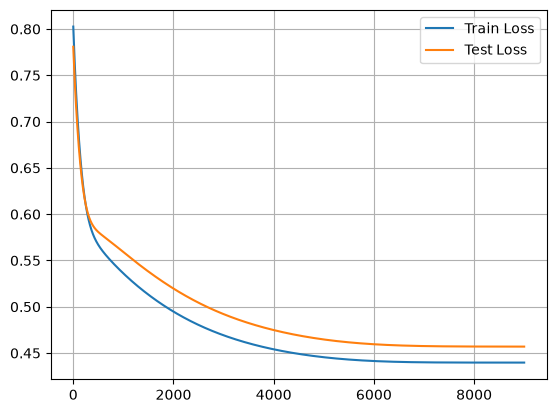

In [65]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.grid(True)
# plt.ylim(0, 1)

[[369  70]
 [ 77 196]]


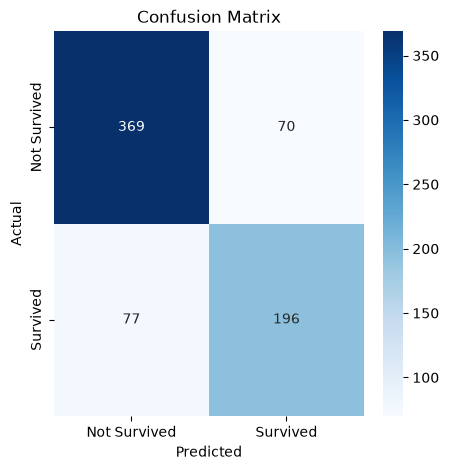

In [66]:
# confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

with torch.no_grad():
    y_pred = model(X)
    y_pred = torch.sigmoid(y_pred)
    y_pred_cls = y_pred.round()
    cm = confusion_matrix(y, y_pred_cls)
    print(cm)

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

## Overfit

In [67]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import torch

df = sns.load_dataset("titanic")
df.head()
# keep only these 7 features
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
df.to_csv("titanic.csv", index=False)
# df = df[df['age'].notnull()]
df['age'] = df['age'].fillna(df['age'].median())


# one hot conversion for categorical variables
# drop_first = True; 2 hi category hain , male and female. 
# Either male = 1 and female = 0 or vice versa.
# notice that the sum of the two columns will always be 1. 
# To do column kyon rakhna hai jab ek hi column se kaam chal jaaye. So, we drop one column.
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=float) 
df.head()


train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["survived"]
)


# standard scaler
scaler = StandardScaler()
# apply scaler to the features
continuous = ['age', 'fare']

scaler = StandardScaler()
train_df[continuous] = scaler.fit_transform(train_df[continuous])
test_df[continuous] = scaler.transform(test_df[continuous])

train_df.head()
test_df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male
565,0,3,-0.419170,2,0,-0.159704,1.0
160,0,3,1.116290,0,1,-0.327324,1.0
553,1,3,-0.572716,0,0,-0.512122,1.0
860,0,3,0.885971,2,0,-0.368795,1.0
241,1,3,-0.112078,1,0,-0.339817,0.0


In [68]:
X = torch.tensor(train_df.drop('survived', axis=1).values, dtype=torch.float32)
y = torch.tensor(train_df['survived'].values, dtype=torch.float32)
Xtest = torch.tensor(test_df.drop('survived', axis=1).values, dtype=torch.float32)
ytest = torch.tensor(test_df['survived'].values, dtype=torch.float32)
print(X.shape, y.shape)
y = y.view(-1, 1)
ytest = ytest.view(-1, 1)
print(X.shape, y.shape)
print(Xtest.shape, ytest.shape)

# X, y

torch.Size([712, 6]) torch.Size([712])
torch.Size([712, 6]) torch.Size([712, 1])
torch.Size([179, 6]) torch.Size([179, 1])


In [69]:
class TitanicModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(6, 16)  # 6 input features, 16 hidden features
        self.fc2 = torch.nn.Linear(16, 8)  # 16 hidden features, 8 output features
        self.fc3 = torch.nn.Linear(8, 4)  # 8 output features, 4 hidden features
        self.fc4 = torch.nn.Linear(4, 1)  # 4 hidden features, 1 output feature
        self.relu = torch.nn.ReLU()
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x


model = TitanicModel()
criterion = torch.nn.BCEWithLogitsLoss()  # binary cross entropy loss with logits
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_losses = []



In [72]:
from torchinfo import summary
print(summary(model, input_size=(X.shape[0], X.shape[1])))

Layer (type:depth-idx)                   Output Shape              Param #
TitanicModel                             [712, 1]                  --
├─Linear: 1-1                            [712, 16]                 112
├─ReLU: 1-2                              [712, 16]                 --
├─Linear: 1-3                            [712, 8]                  136
├─ReLU: 1-4                              [712, 8]                  --
├─Linear: 1-5                            [712, 4]                  36
├─ReLU: 1-6                              [712, 4]                  --
├─Linear: 1-7                            [712, 1]                  5
Total params: 289
Trainable params: 289
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.21
Input size (MB): 0.02
Forward/backward pass size (MB): 0.17
Params size (MB): 0.00
Estimated Total Size (MB): 0.18


In [73]:
epochs = 3000

for epoch in range(epochs):
    # forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(Xtest), ytest)
        test_losses.append(test_loss.item())
    model.train()
    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/3000], Loss: 0.6780
Epoch [101/3000], Loss: 0.5928
Epoch [201/3000], Loss: 0.4421
Epoch [301/3000], Loss: 0.4111
Epoch [401/3000], Loss: 0.3949
Epoch [501/3000], Loss: 0.3847
Epoch [601/3000], Loss: 0.3772
Epoch [701/3000], Loss: 0.3697
Epoch [801/3000], Loss: 0.3617
Epoch [901/3000], Loss: 0.3543
Epoch [1001/3000], Loss: 0.3478
Epoch [1101/3000], Loss: 0.3411
Epoch [1201/3000], Loss: 0.3371
Epoch [1301/3000], Loss: 0.3339
Epoch [1401/3000], Loss: 0.3308
Epoch [1501/3000], Loss: 0.3279
Epoch [1601/3000], Loss: 0.3246
Epoch [1701/3000], Loss: 0.3223
Epoch [1801/3000], Loss: 0.3201
Epoch [1901/3000], Loss: 0.3181
Epoch [2001/3000], Loss: 0.3165
Epoch [2101/3000], Loss: 0.3149
Epoch [2201/3000], Loss: 0.3137
Epoch [2301/3000], Loss: 0.3126
Epoch [2401/3000], Loss: 0.3116
Epoch [2501/3000], Loss: 0.3108
Epoch [2601/3000], Loss: 0.3097
Epoch [2701/3000], Loss: 0.3089
Epoch [2801/3000], Loss: 0.3076
Epoch [2901/3000], Loss: 0.3060


In [74]:
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        return (preds == y).float().mean().item()

In [75]:
# accuracy on test set
print(f"Training Accuracy: {accuracy(model, X, y):.4f}")
print(f"Test Accuracy: {accuracy(model, Xtest, ytest):.4f}")



Training Accuracy: 0.8736
Test Accuracy: 0.7821


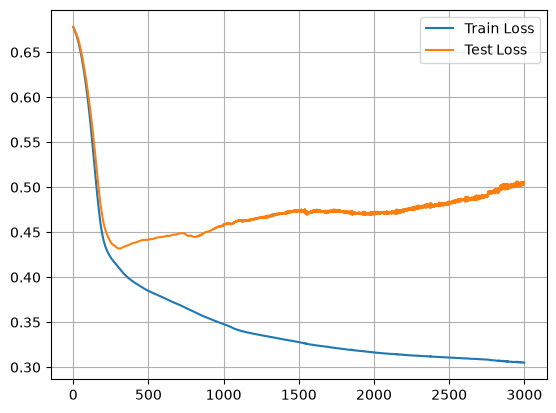

In [76]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.grid(True)
# plt.ylim(0, 1)

[[97 13]
 [26 43]]


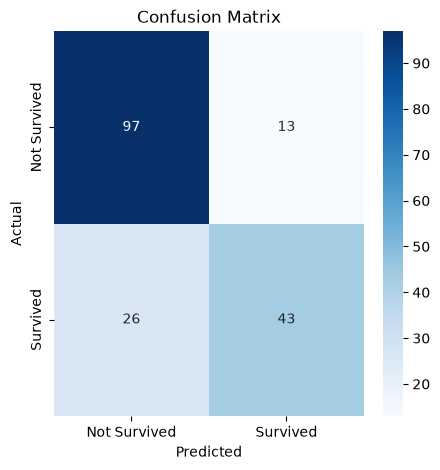

In [77]:
# confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

with torch.no_grad():
    y_pred = model(Xtest)
    y_pred = torch.sigmoid(y_pred)
    y_pred_cls = y_pred.round()
    cm = confusion_matrix(ytest, y_pred_cls)
    print(cm)

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()